In [10]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\fireprotdb_ddg_final_all_ver2.csv", low_memory=False)

In [11]:
df

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE
0,1A0N,A,12,C,-1.271679,MegaScale,NaN,NaN,1A0N
1,1A0N,A,12,D,-2.513681,MegaScale,NaN,NaN,1A0N
2,1A0N,A,12,E,-2.120722,MegaScale,NaN,NaN,1A0N
3,1A0N,A,12,F,-2.238222,MegaScale,NaN,NaN,1A0N
4,1A0N,A,12,G,-0.142810,MegaScale,NaN,NaN,1A0N
...,...,...,...,...,...,...,...,...,...
347020,v2_6IVS,Y,7,R,0.056541,MegaScale,NaN,NaN,v2_6IVS
347021,v2_6IVS,Y,7,S,-0.514305,MegaScale,NaN,NaN,v2_6IVS
347022,v2_6IVS,Y,7,T,-0.211927,MegaScale,NaN,NaN,v2_6IVS
347023,v2_6IVS,Y,7,V,-0.062451,MegaScale,NaN,NaN,v2_6IVS


In [12]:
df_uni = df[df["SOURCE_DATASET"]!="MegaScale"].copy()
df_mega = df[df["SOURCE_DATASET"]=="MegaScale"].copy()

In [13]:
df_uni

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE
300578,O26594,V,92,L,1.100000,ProTherm,O26594,NaN,NaN
300579,O49003,C,450,A,-0.480000,ProTherm,O49003,2V0U,NaN
300580,O61594,A,263,F,0.430000,ProTherm,O61594,5CG0,NaN
300581,O61594,D,260,A,0.670000,ProTherm,O61594,5CG0,NaN
300582,O61594,E,261,A,-0.530000,ProTherm,O61594,5CG0,NaN
...,...,...,...,...,...,...,...,...,...
306067,R9S082,T,68,A,0.300000,ProTherm,R9S082,NaN,NaN
306068,R9S082,V,115,A,1.400000,ProTherm,R9S082,NaN,NaN
306069,R9S082,V,14,A,0.000000,ProTherm,R9S082,NaN,NaN
306070,R9S082,V,69,T,0.400000,ProTherm,R9S082,NaN,NaN


In [14]:
import pandas as pd
import requests
import os

In [15]:
# 1. UNIPROTKB에서 첫 번째 ID만 추출
df_uni['UP_ID_CLEAN'] = df_uni['UNIPROTKB'].str.split(',').str[0].str.strip()

# 2. 고유한 (UniProt ID, PDB_ID) 쌍 추출 (효율적인 루프를 위해)
unique_targets = df_uni[['UP_ID_CLEAN', 'PDB_ID']].drop_duplicates().reset_index(drop=True)

print(f"전체 로우: {len(df_uni)} -> 처리할 유니크 타겟: {len(unique_targets)}")

전체 로우: 4350 -> 처리할 유니크 타겟: 182


In [16]:
def download_pdb(uniprot_id, pdb_id, save_dir="./pdb_files"):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # 결과 저장용 변수
    source = None
    file_path = None

    # # 1. RCSB PDB 시도 (PDB_ID가 존재할 때)
    # if pd.notna(pdb_id) and pdb_id != 'NaN':
    #     pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    #     try:
    #         res = requests.get(pdb_url)
    #         if res.status_code == 200:
    #             file_path = os.path.join(save_dir, f"{pdb_id}.pdb")
    #             with open(file_path, 'w') as f:
    #                 f.write(res.text)
    #             return pdb_id, "RCSB_PDB", file_path
    #     except:
    #         pass

    # 2. AlphaFold DB 시도 (UniProt ID 기반)
    af_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    try:
        res = requests.get(af_url).json()
        if res and len(res) > 0:
            # 가장 최신 entry의 pdb url 가져오기
            pdb_url = res[0]['pdbUrl']
            file_path = os.path.join(save_dir, f"{uniprot_id}_AF.pdb")
            pdb_content = requests.get(pdb_url).text
            with open(file_path, 'w') as f:
                f.write(pdb_content)
            return uniprot_id, "AlphaFold", file_path
    except:
        pass

    return None, "Failed", None

In [17]:
results = []

for idx, row in unique_targets.iterrows():
    up_id = row['UP_ID_CLEAN']
    pdb_id = row['PDB_ID']
    
    print(f"[{idx+1}/{len(unique_targets)}] Processing: {up_id}...", end='\r')
    
    found_id, source, path = download_pdb(up_id, pdb_id)
    results.append({
        'UP_ID_CLEAN': up_id,
        'PDB_ID': pdb_id,
        'FETCHED_ID': found_id,
        'STRUCTURE_SOURCE': source,
        'FILE_PATH': path
    })

# 결과를 데이터프레임으로 변환 후 병합
df_results = pd.DataFrame(results)
df_final = pd.merge(df_uni, df_results, on=['UP_ID_CLEAN', 'PDB_ID'], how='left')

 [ 수집 결과 요약 ]
      Source  Count  Percentage (%)
0  AlphaFold    169           92.86
1     Failed     13            7.14
------------------------------
총 고유 ID 개수: 182
성공: 169 (92.86%)
실패: 13 (7.14%)


C:\Users\Kunny\AppData\Local\Temp\ipykernel_20180\3088962862.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_stats, x='Source', y='Count', palette='viridis')


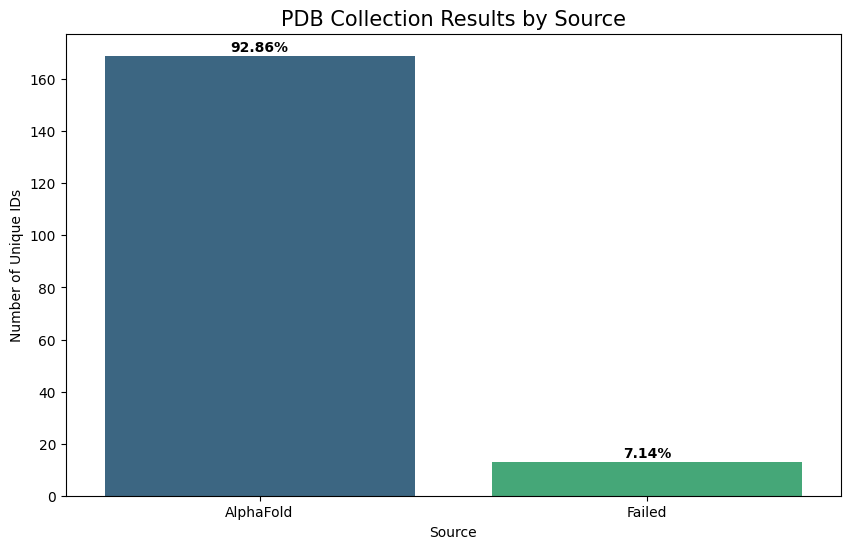


 [ 실패한 UniProt ID (상위 10개) ]
['P00720', 'P01607', 'P03034', 'P03040', 'P03050', 'P03706', 'P12528', 'P12823', 'P23074', 'P69168']


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 소스별 수량 및 비율 계산
source_stats = df_results['STRUCTURE_SOURCE'].value_counts().reset_index()
source_stats.columns = ['Source', 'Count']
source_stats['Percentage (%)'] = (source_stats['Count'] / len(df_results) * 100).round(2)

print(" [ 수집 결과 요약 ]")
print(source_stats)
print("-" * 30)

# 2. 성공률 계산
total = len(df_results)
success = len(df_results[df_results['STRUCTURE_SOURCE'] != 'Failed'])
fail = total - success
print(f"총 고유 ID 개수: {total}")
print(f"성공: {success} ({success/total*100:.2f}%)")
print(f"실패: {fail} ({fail/total*100:.2f}%)")

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
sns.barplot(data=source_stats, x='Source', y='Count', palette='viridis')
plt.title('PDB Collection Results by Source', fontsize=15)
for i, row in source_stats.iterrows():
    plt.text(i, row['Count'] + (total*0.01), f"{row['Percentage (%)']}%", ha='center', fontweight='bold')
plt.ylabel('Number of Unique IDs')
plt.show()

# 4. 실패한 리스트 따로 뽑아보기 (원인 분석용)
failed_df = df_results[df_results['STRUCTURE_SOURCE'] == 'Failed']
if not failed_df.empty:
    print("\n [ 실패한 UniProt ID (상위 10개) ]")
    print(failed_df['UP_ID_CLEAN'].head(10).tolist())

In [24]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_one, is_aa

def verify_with_chain_mapping(row):
    if pd.isna(row['FILE_PATH']) or row['STRUCTURE_SOURCE'] == 'Failed':
        return "No_File", None
    
    up_id = row['UP_ID_CLEAN']
    target_pos = int(row['POS'])
    target_wt = row['WT']
    
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('protein', row['FILE_PATH'])
        model = structure[0]
        
        # 1. PDB 파일 헤더에서 UniProt ID와 매핑된 체인 찾기
        # (AlphaFold는 보통 헤더가 없으므로 별도 처리)
        matched_chains = []
        
        if row['STRUCTURE_SOURCE'] == 'RCSB_PDB':
            header = parser.get_header()
            # DBREF 정보를 통해 UniProt ID와 연결된 체인 리스트 추출
            # Biopython의 header 파싱은 제한적이므로, 체인을 직접 돌며 검증하는 것이 더 확실할 수 있음
            pass 

        # 2. 모든 체인을 검사하되, UniProt ID와 매핑 여부를 확인
        for chain in model:
            # 해당 위치에 잔기가 있는지 확인
            if target_pos in chain:
                res = chain[target_pos]
                if is_aa(res):
                    res_name_1 = three_to_one(res.get_resname())
                    
                    # WT가 일치하는 체인을 찾으면 즉시 반환
                    if res_name_1 == target_wt:
                        return "Match", chain.id
        
        return "Mismatch_or_Not_Found", None
        
    except Exception as e:
        return f"Error: {str(e)}", None

# 적용 (결과가 2개이므로 zip 사용)
print("정밀 체인 매핑 시작...")
results = df_final.apply(verify_with_chain_mapping, axis=1)
df_final[['MAPPING_STATUS', 'MATCHED_CHAIN']] = pd.DataFrame(results.tolist(), index=df_final.index)

정밀 체인 매핑 시작...


=== [ 매핑 실패 원인 통계 ] ===
          Failure_Reason  Count  Percentage (%)
0                No_File    448           99.78
1  Mismatch_or_Not_Found      1            0.22
----------------------------------------


C:\Users\Kunny\AppData\Local\Temp\ipykernel_24120\4124096881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fail_stats, x='Failure_Reason', y='Count', palette='magma')


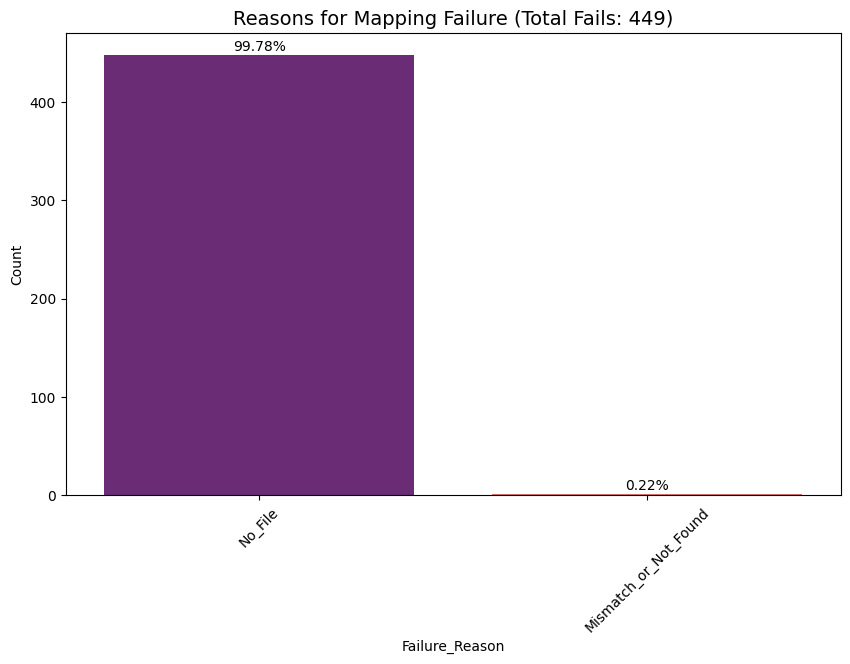

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 실패한 데이터만 추출
df_fail = df_final[df_final["MAPPING_STATUS"] != "Match"].copy()

# 2. 실패 원인별 통계 (Value Counts)
fail_stats = df_fail["MAPPING_STATUS"].value_counts().reset_index()
fail_stats.columns = ['Failure_Reason', 'Count']
fail_stats['Percentage (%)'] = (fail_stats['Count'] / len(df_fail) * 100).round(2)

print("=== [ 매핑 실패 원인 통계 ] ===")
print(fail_stats)
print("-" * 40)

# 3. 주요 원인 분석 가이드
# - No_File: PDB/AlphaFold 다운로드 자체를 실패함 (네트워크 혹은 ID 부재)
# - POS_Not_Found: 구조 파일은 있으나, 해당 POS 번호가 구조 내에 없음 (주로 RCSB PDB의 결실 영역)
# - Mismatch(X): 번호는 있으나 해당 위치의 아미노산이 다름 (주로 RCSB PDB의 번호 밀림 이슈)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=fail_stats, x='Failure_Reason', y='Count', palette='magma')
plt.title(f"Reasons for Mapping Failure (Total Fails: {len(df_fail)})", fontsize=14)
for i, row in fail_stats.iterrows():
    plt.text(i, row['Count'] + (len(df_fail)*0.01), f"{row['Percentage (%)']}%", ha='center')
plt.xticks(rotation=45)
plt.show()

In [26]:
df_cleaned = df_final[df_final['MAPPING_STATUS'] == 'Match'].copy()

In [37]:
df_final[df_final["UNIPROTKB"]=="P11532"]

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE,UP_ID_CLEAN,FETCHED_ID,STRUCTURE_SOURCE,FILE_PATH,MAPPING_STATUS,MATCHED_CHAIN
3609,P11532,K,18,N,3.7,ProTherm,P11532,1DXX,NaN,P11532,P11532,AlphaFold,./pdb_files\P11532_AF.pdb,Mismatch_or_Not_Found,None


In [ ]:
import os

# 1. 저장 경로 설정
save_path = os.path.join(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB", "df_cleaned_final_not_Mega_only_AF.csv")

# 2. 파일 저장 (인덱스 제외, UTF-8 인코딩)
df_cleaned.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 저장 완료: {save_path}")
print("-" * 50)

# 3. 저장된 데이터 최종 요약
print(f"📂 최종 데이터 로우 수: {len(df_cleaned):,} 개")
print(f"🧬 유니크 단백질(UniProtID) 수: {df_cleaned['UP_ID_CLEAN'].nunique():,} 개")
print(f"구조 출처별 분포:\n{df_cleaned['STRUCTURE_SOURCE'].value_counts()}")
print("-" * 50)

# 4. 제대로 저장됐는지 확인 (상위 5개 샘플 출력)
print("👀 최종 데이터 샘플:")
display(df_cleaned[['UP_ID_CLEAN', 'POS', 'WT', 'PDB_ID', 'MATCHED_CHAIN', 'STRUCTURE_SOURCE']].head())

✅ 저장 완료: C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\df_cleaned_final_not_Mega_only_AF.csv
--------------------------------------------------
📂 최종 데이터 로우 수: 3,901 개
🧬 유니크 단백질(UniProtID) 수: 168 개
구조 출처별 분포:
STRUCTURE_SOURCE
AlphaFold    3901
Name: count, dtype: int64
--------------------------------------------------
👀 최종 데이터 샘플:


,UP_ID_CLEAN,POS,WT,PDB_ID,MATCHED_CHAIN,STRUCTURE_SOURCE
0,O26594,92,V,NaN,A,AlphaFold
1,O49003,450,C,2V0U,A,AlphaFold
2,O61594,263,A,5CG0,A,AlphaFold
3,O61594,260,D,5CG0,A,AlphaFold
4,O61594,261,E,5CG0,A,AlphaFold


In [29]:
import pandas as pd

df_notMega = pd.read_csv(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\df_cleaned_final_not_Mega_only_AF.csv")
df_notMega

,PROTEIN_ID,WT,POS,MUT,DDG_mean,SOURCE_DATASET,UNIPROTKB,PDB_ID,MEGASCALE,UP_ID_CLEAN,FETCHED_ID,STRUCTURE_SOURCE,FILE_PATH,MAPPING_STATUS,MATCHED_CHAIN
0,O26594,V,92,L,1.100000,ProTherm,O26594,NaN,NaN,O26594,O26594,AlphaFold,./pdb_files\O26594_AF.pdb,Match,A
1,O49003,C,450,A,-0.480000,ProTherm,O49003,2V0U,NaN,O49003,O49003,AlphaFold,./pdb_files\O49003_AF.pdb,Match,A
2,O61594,A,263,F,0.430000,ProTherm,O61594,5CG0,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
3,O61594,D,260,A,0.670000,ProTherm,O61594,5CG0,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
4,O61594,E,261,A,-0.530000,ProTherm,O61594,5CG0,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,R9S082,T,68,A,0.300000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
3897,R9S082,V,115,A,1.400000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
3898,R9S082,V,14,A,0.000000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
3899,R9S082,V,69,T,0.400000,ProTherm,R9S082,NaN,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A


In [30]:
df_notMega = df_notMega.drop(columns=["PDB_ID"])

df_notMega = df_notMega.rename(columns={
    "MUT": "Mut",
    "POS": "MutPos",
    "DDG_mean": "DDG",
    "UP_ID_CLEAN": "PDB_ID",
    "MATCHED_CHAIN": "Chain"
})

In [31]:
df_notMega

,PROTEIN_ID,WT,MutPos,Mut,DDG,SOURCE_DATASET,UNIPROTKB,MEGASCALE,PDB_ID,FETCHED_ID,STRUCTURE_SOURCE,FILE_PATH,MAPPING_STATUS,Chain
0,O26594,V,92,L,1.100000,ProTherm,O26594,NaN,O26594,O26594,AlphaFold,./pdb_files\O26594_AF.pdb,Match,A
1,O49003,C,450,A,-0.480000,ProTherm,O49003,NaN,O49003,O49003,AlphaFold,./pdb_files\O49003_AF.pdb,Match,A
2,O61594,A,263,F,0.430000,ProTherm,O61594,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
3,O61594,D,260,A,0.670000,ProTherm,O61594,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
4,O61594,E,261,A,-0.530000,ProTherm,O61594,NaN,O61594,O61594,AlphaFold,./pdb_files\O61594_AF.pdb,Match,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,R9S082,T,68,A,0.300000,ProTherm,R9S082,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
3897,R9S082,V,115,A,1.400000,ProTherm,R9S082,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
3898,R9S082,V,14,A,0.000000,ProTherm,R9S082,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A
3899,R9S082,V,69,T,0.400000,ProTherm,R9S082,NaN,R9S082,R9S082,AlphaFold,./pdb_files\R9S082_AF.pdb,Match,A


In [32]:
df_notMega = df_notMega.drop(columns=["PROTEIN_ID","SOURCE_DATASET","MEGASCALE","UNIPROTKB","FETCHED_ID", "STRUCTURE_SOURCE","MAPPING_STATUS"])

In [35]:
import os

# FILE_PATH 컬럼에서 파일명만 추출하여 덮어쓰기
df_notMega['FILE_PATH'] = df_notMega['FILE_PATH'].apply(lambda x: os.path.basename(x))

df_notMega

,WT,MutPos,Mut,DDG,PDB_ID,FILE_PATH,Chain
0,V,92,L,1.100000,O26594,O26594_AF.pdb,A
1,C,450,A,-0.480000,O49003,O49003_AF.pdb,A
2,A,263,F,0.430000,O61594,O61594_AF.pdb,A
3,D,260,A,0.670000,O61594,O61594_AF.pdb,A
4,E,261,A,-0.530000,O61594,O61594_AF.pdb,A
...,...,...,...,...,...,...,...
3896,T,68,A,0.300000,R9S082,R9S082_AF.pdb,A
3897,V,115,A,1.400000,R9S082,R9S082_AF.pdb,A
3898,V,14,A,0.000000,R9S082,R9S082_AF.pdb,A
3899,V,69,T,0.400000,R9S082,R9S082_AF.pdb,A


In [38]:
df_notMega

,WT,MutPos,Mut,DDG,PDB_ID,FILE_PATH,Chain
0,V,92,L,1.100000,O26594,O26594_AF.pdb,A
1,C,450,A,-0.480000,O49003,O49003_AF.pdb,A
2,A,263,F,0.430000,O61594,O61594_AF.pdb,A
3,D,260,A,0.670000,O61594,O61594_AF.pdb,A
4,E,261,A,-0.530000,O61594,O61594_AF.pdb,A
...,...,...,...,...,...,...,...
3896,T,68,A,0.300000,R9S082,R9S082_AF.pdb,A
3897,V,115,A,1.400000,R9S082,R9S082_AF.pdb,A
3898,V,14,A,0.000000,R9S082,R9S082_AF.pdb,A
3899,V,69,T,0.400000,R9S082,R9S082_AF.pdb,A


In [39]:
import pandas as pd
import os
from Bio.PDB import PDBParser, PPBuilder

def generate_s669_fasta_with_pos(df, pdb_dir, output_file):
    parser = PDBParser(QUIET=True)
    ppb = PPBuilder()
    
    # 3문자 -> 1문자 변환용 (PPBuilder 내부에서 쓰이지만 매핑 확인용으로 선언)
    d3to1 = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 
             'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 
             'ARG': 'R', 'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'}

    # 결과를 저장할 리스트 (나중에 df에 합침)
    seq_pos_list = [None] * len(df)
    
    # 유니크한 PDB-Chain 조합별로 처리
    unique_targets = df[['PDB_ID', 'Chain','FILE_PATH']].drop_duplicates()
    
    print(f"--- FASTA 생성 및 포지션 매핑 시작 ---")
    
    with open(output_file, 'w') as f_out:
        for _, target in unique_targets.iterrows():
            pdb_id, chain_id, file_path = target['PDB_ID'], target['Chain'], target["FILE_PATH"]
            pdb_path = os.path.join(pdb_dir, f"{file_path}")
            
            if not os.path.exists(pdb_path):
                continue
                
            try:
                structure = parser.get_structure(pdb_id, pdb_path)
                model = structure[0]
                if chain_id not in model: continue
                
                # 1. PPBuilder로 물리적으로 연결된 서열 조각(Polypeptides) 추출
                polypeptides = ppb.build_peptides(model[chain_id])
                
                full_seq = ""
                # FASTA 내 각 글자가 실제 PDB에서 몇 번이었는지 기록할 리스트
                pdb_res_nums = [] 

                for pp in polypeptides:
                    full_seq += str(pp.get_sequence())
                    # 각 잔기의 PDB 번호(id[1])를 순서대로 추출
                    for residue in pp:
                        pdb_res_nums.append(residue.get_id()[1])
                
                if not full_seq: continue

                # 2. FASTA 파일 쓰기
                f_out.write(f">{pdb_id}_{chain_id}\n{full_seq}\n")

                # 3. 해당 PDB_ID/Chain을 쓰는 모든 행(Mutation)에 대해 SeqPos 계산
                row_indices = df[(df['PDB_ID'] == pdb_id) & (df['Chain'] == chain_id)].index
                
                for idx in row_indices:
                    target_pdb_pos = int(df.at[idx, 'MutPos'])
                    
                    # PDB 번호 리스트에서 해당 번호가 몇 번째(index)에 있는지 찾기
                    try:
                        # 0-based index에 1을 더해 1-based position 생성
                        seq_index = pdb_res_nums.index(target_pdb_pos)
                        seq_pos_list[idx] = seq_index + 1 
                    except ValueError:
                        # PDB 구조에 좌표가 없는 번호인 경우
                        seq_pos_list[idx] = None
                        
            except Exception as e:
                print(f"Error in {pdb_id}_{chain_id}: {e}")

    # 4. 데이터프레임 업데이트
    df['SeqPos'] = seq_pos_list
    print(f"--- 완료! FASTA가 저장되었고 df_zenodo에 'SeqPos' 컬럼이 추가되었습니다. ---")
    return df

# --- 실행 부분 ---
pdb_dir_path = r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\pdb_files"
output_fasta = "notMega.fasta"

# 함수 실행 및 결과 업데이트
df_notMega = generate_s669_fasta_with_pos(df_notMega, pdb_dir_path, output_fasta)

# 결과 확인
print(df_notMega[['PDB_ID', 'Chain', 'MutPos', 'SeqPos', 'WT']].head())

--- FASTA 생성 및 포지션 매핑 시작 ---
--- 완료! FASTA가 저장되었고 df_zenodo에 'SeqPos' 컬럼이 추가되었습니다. ---
   PDB_ID Chain  MutPos  SeqPos WT
0  O26594     A      92      92  V
1  O49003     A     450     450  C
2  O61594     A     263     263  A
3  O61594     A     260     260  D
4  O61594     A     261     261  E


In [40]:
df_notMega.to_csv("notMega.tsv", sep='\t', index=False)

In [41]:
df_notMega

,WT,MutPos,Mut,DDG,PDB_ID,FILE_PATH,Chain,SeqPos
0,V,92,L,1.100000,O26594,O26594_AF.pdb,A,92
1,C,450,A,-0.480000,O49003,O49003_AF.pdb,A,450
2,A,263,F,0.430000,O61594,O61594_AF.pdb,A,263
3,D,260,A,0.670000,O61594,O61594_AF.pdb,A,260
4,E,261,A,-0.530000,O61594,O61594_AF.pdb,A,261
...,...,...,...,...,...,...,...,...
3896,T,68,A,0.300000,R9S082,R9S082_AF.pdb,A,68
3897,V,115,A,1.400000,R9S082,R9S082_AF.pdb,A,115
3898,V,14,A,0.000000,R9S082,R9S082_AF.pdb,A,14
3899,V,69,T,0.400000,R9S082,R9S082_AF.pdb,A,69


In [42]:
df_notMega["Key"] = df_notMega["PDB_ID"] + "_" + df_notMega["Chain"]

In [43]:
df_notMega.to_csv("notMega.tsv", sep='\t', index=False)

In [44]:
df_notMega

,WT,MutPos,Mut,DDG,PDB_ID,FILE_PATH,Chain,SeqPos,Key
0,V,92,L,1.100000,O26594,O26594_AF.pdb,A,92,O26594_A
1,C,450,A,-0.480000,O49003,O49003_AF.pdb,A,450,O49003_A
2,A,263,F,0.430000,O61594,O61594_AF.pdb,A,263,O61594_A
3,D,260,A,0.670000,O61594,O61594_AF.pdb,A,260,O61594_A
4,E,261,A,-0.530000,O61594,O61594_AF.pdb,A,261,O61594_A
...,...,...,...,...,...,...,...,...,...
3896,T,68,A,0.300000,R9S082,R9S082_AF.pdb,A,68,R9S082_A
3897,V,115,A,1.400000,R9S082,R9S082_AF.pdb,A,115,R9S082_A
3898,V,14,A,0.000000,R9S082,R9S082_AF.pdb,A,14,R9S082_A
3899,V,69,T,0.400000,R9S082,R9S082_AF.pdb,A,69,R9S082_A


In [9]:
import pandas as pd

def analyze_pos_differences(df):
    # 1. 오프셋 계산 (PDB번호 - FASTA순서)
    # SeqPos가 NaN인 경우(구조에 좌표가 없는 경우)는 제외하고 계산합니다.
    df_valid = df.dropna(subset=['SeqPos']).copy()
    df_valid['Offset'] = df_valid['MutPos'].astype(int) - df_valid['SeqPos'].astype(int)

    # 2. Key 단위로 그룹화하여 통계 산출
    key_stats = df_valid.groupby('Key')['Offset'].agg(['min', 'max', 'mean', 'nunique', 'std']).reset_index()
    
    # 3. 결과 분석 및 카운팅
    # 오프셋이 일정한 그룹 (std == 0 또는 nunique == 1)
    consistent_keys = key_stats[key_stats['nunique'] == 1]
    
    # 오프셋이 상이한 그룹 (중간에 Gap이 있거나 구조가 끊긴 경우)
    inconsistent_keys = key_stats[key_stats['nunique'] > 1]
    
    # [추가] 오프셋이 0이 아닌 케이스 계산
    # 1) 일정한데 0이 아닌 경우 (단순 오프셋 존재)
    nonzero_consistent = consistent_keys[consistent_keys['min'] != 0]
    # 2) 일정하지 않은 경우 (Gap 존재 등, 당연히 0이 아님)
    nonzero_total_count = len(nonzero_consistent) + len(inconsistent_keys)
    # 3) 완벽하게 1:1 매칭되는 경우 (Offset이 0인 경우)
    perfect_match_count = len(consistent_keys[consistent_keys['min'] == 0])

    print(f" 전체 요약 ")
    print(f"- 분석 대상 Key 개수: {len(key_stats)}")
    print(f"- 오프셋이 0인 Key (완벽 일치): {perfect_match_count}")
    print(f"- 오프셋이 0이 아닌 Key (오프셋/Gap 존재): {nonzero_total_count}") # 요청하신 부분
    print(f"  └ 오프셋이 일정하나 0은 아님: {len(nonzero_consistent)}")
    print(f"  └ 오프셋이 불규칙함 (Gap 의심): {len(inconsistent_keys)}")
    print("-" * 30)

    if not inconsistent_keys.empty:
        print("\n[ 오프셋이 상이한 Key 리스트 (주의 필요) ]")
        print(inconsistent_keys.sort_values('std', ascending=False).head(10))
    
    if not nonzero_consistent.empty:
        print("\n[ 오프셋이 일정하지만 0은 아닌 Key 샘플 ]")
        print(nonzero_consistent[['Key', 'min']].rename(columns={'min': 'Constant_Offset'}).head(10))

    return key_stats, inconsistent_keys

# 실행 예시
df_notMega = pd.read_csv(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\FireProtDB\notMega.tsv", sep="\t")
key_summary, gap_keys = analyze_pos_differences(df_notMega)

 전체 요약 
- 분석 대상 Key 개수: 168
- 오프셋이 0인 Key (완벽 일치): 168
- 오프셋이 0이 아닌 Key (오프셋/Gap 존재): 0
  └ 오프셋이 일정하나 0은 아님: 0
  └ 오프셋이 불규칙함 (Gap 의심): 0
------------------------------
